In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/crop_clean.csv")

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [8]:
print(df.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'rainfall_category', 'temperature_category', 'humidity_category'],
      dtype='str')


In [7]:
df["rainfall_category"] = pd.cut(
    df["rainfall"],
    bins=[0, 100, 200, 400],
    labels=["Low", "Medium", "High"]
)

df["temperature_category"] = pd.cut(
    df["temperature"],
    bins=[0, 20, 30, 50],
    labels=["Cool", "Moderate", "Hot"]
)

df["humidity_category"] = pd.cut(
    df["humidity"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"]
)

print("Feature columns created successfully!")

Feature columns created successfully!


In [9]:
print("\n RAINFALL CATEGORIES BY CROP\n")

rainfall_analysis = df.groupby("rainfall_category")["label"].value_counts()

for cat in ['High', 'Medium', 'Low']:
    print(f"**{cat} Rainfall:**")
    crops = rainfall_analysis[cat].loc[lambda x: x > 0]
    for crop, count in crops.items():
        print(f"   • {crop}: {count}")
    print("-" * 40)


 RAINFALL CATEGORIES BY CROP

**High Rainfall:**
   • rice: 80
   • papaya: 26
   • coconut: 26
----------------------------------------
**Medium Rainfall:**
   • orange: 100
   • apple: 100
   • coffee: 100
   • jute: 100
   • pomegranate: 100
   • pigeonpeas: 91
   • coconut: 74
   • banana: 62
   • kidneybeans: 62
   • papaya: 41
   • maize: 25
   • rice: 20
   • mango: 6
----------------------------------------
**Low Rainfall:**
   • mothbeans: 100
   • muskmelon: 100
   • lentil: 100
   • blackgram: 100
   • mungbean: 100
   • grapes: 100
   • watermelon: 100
   • chickpea: 100
   • cotton: 100
   • mango: 94
   • maize: 75
   • banana: 38
   • kidneybeans: 38
   • papaya: 33
   • pigeonpeas: 9
----------------------------------------


## Rainfall Categories by Crop
The dataset shows clear rainfall preferences among crops. Rice strongly dominates the high rainfall category, along with coconut, jute, and papaya. Most crops, including apple, coffee, grapes, orange, and pomegranate, fall into the medium rainfall range. Several pulses and melons such as blackgram, chickpea, cotton, mungbean, and muskmelon primarily require low rainfall. This distribution confirms that rainfall is an important distinguishing feature for crop recommendation.

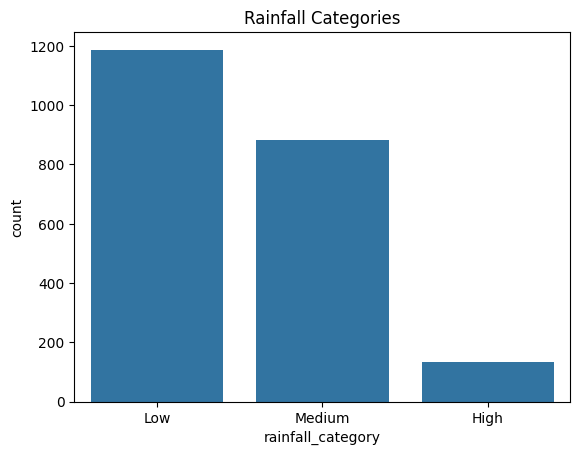

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x="rainfall_category",
    data=df
)

plt.title("Rainfall Categories")
plt.show()

In [11]:
print(" TEMPERATURE CATEGORIES BY CROP\n")
temp_analysis = df.groupby("temperature_category", observed=False)["label"].value_counts()

for cat in ['Hot', 'Moderate', 'Cool']:
    print(f"**{cat} Temperature:**")
    crops = temp_analysis[cat].loc[lambda x: x > 0]
    for crop, count in crops.items():
        print(f"   • {crop}: {count}")
    print("-" * 40)

 TEMPERATURE CATEGORIES BY CROP

**Hot Temperature:**
   • papaya: 68
   • mango: 65
   • blackgram: 48
   • pigeonpeas: 40
   • grapes: 27
   • mothbeans: 27
   • orange: 23
----------------------------------------
**Moderate Temperature:**
   • apple: 100
   • rice: 100
   • muskmelon: 100
   • watermelon: 100
   • coffee: 100
   • cotton: 100
   • mungbean: 100
   • banana: 100
   • coconut: 100
   • jute: 100
   • lentil: 89
   • maize: 73
   • mothbeans: 73
   • pomegranate: 70
   • blackgram: 52
   • kidneybeans: 49
   • pigeonpeas: 44
   • orange: 41
   • mango: 35
   • papaya: 32
   • grapes: 32
   • chickpea: 21
----------------------------------------
**Cool Temperature:**
   • chickpea: 79
   • kidneybeans: 51
   • grapes: 41
   • orange: 36
   • pomegranate: 30
   • maize: 27
   • pigeonpeas: 16
   • lentil: 11
----------------------------------------


## Temperature Categories by Crop
Most crops in the dataset prefer moderate temperatures (20–30°C), which is the dominant range for the majority of them. Papaya and mango show a clear preference for hot conditions, followed by pigeonpeas, blackgram, and mothbeans. Chickpea stands out with a strong preference for cool temperatures, along with kidneybeans, grapes, orange, and pomegranate. This highlights temperature as a useful feature for separating warm-season and cool-season crops.

<Axes: xlabel='temperature_category', ylabel='count'>

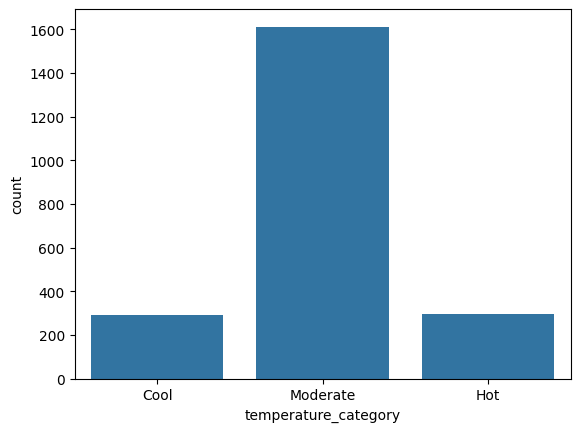

In [12]:
sns.countplot(
    x="temperature_category",
    data=df
)

In [13]:
print(" HUMIDITY CATEGORIES BY CROP\n")

humidity_analysis = df.groupby("humidity_category")["label"].value_counts()

for cat in ['High', 'Medium', 'Low']:
    print(f"**{cat} Humidity:**")
    crops = humidity_analysis[cat].loc[lambda x: x > 0]
    for crop, count in crops.items():
        print(f"   • {crop}: {count}")
    print("-" * 40)

 HUMIDITY CATEGORIES BY CROP

**High Humidity:**
   • cotton: 100
   • coconut: 100
   • papaya: 100
   • orange: 100
   • apple: 100
   • muskmelon: 100
   • rice: 100
   • grapes: 100
   • banana: 100
   • jute: 100
   • mungbean: 100
   • watermelon: 100
   • pomegranate: 100
   • maize: 24
----------------------------------------
**Medium Humidity:**
   • coffee: 100
   • mothbeans: 100
   • blackgram: 100
   • lentil: 100
   • mango: 100
   • maize: 76
   • pigeonpeas: 70
----------------------------------------
**Low Humidity:**
   • chickpea: 100
   • kidneybeans: 100
   • pigeonpeas: 30
----------------------------------------


## Humidity Categories by Crop
Humidity proves to be a highly discriminative feature. The majority of crops, especially fruits like apple, banana, coconut, grapes, orange, papaya, and rice, strongly prefer high humidity conditions. Blackgram, coffee, and mango mainly fall in the medium humidity range. Chickpea and kidneybeans are notable for their tolerance to low humidity. This clear separation makes humidity one of the strongest features for crop classification.

<Axes: xlabel='humidity_category', ylabel='count'>

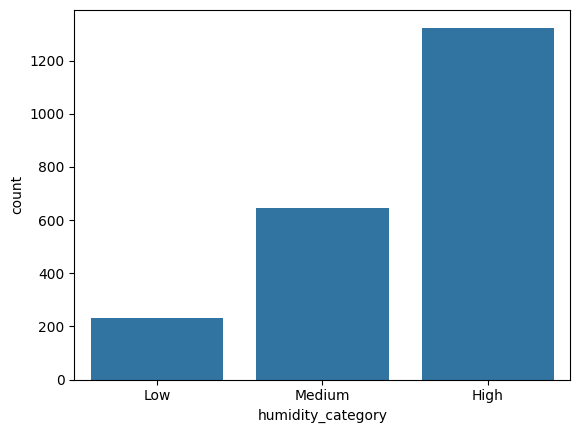

In [14]:
sns.countplot(
    x="humidity_category",
    data=df
)

In [15]:
def season_mapper(temp):
    if temp < 20:
        return "Winter"
    elif temp < 30:
        return "Moderate"
    else:
        return "Summer"

df["season_type"] = df["temperature"].apply(season_mapper)


In [16]:

print(" SEASON-WISE CROP DISTRIBUTION\n")

season_analysis = df.groupby("season_type")["label"].value_counts()

for season in ['Winter', 'Moderate', 'Summer']:
    print(f"**{season}:**")
    crops = season_analysis[season].loc[lambda x: x > 0]
    for crop, count in crops.items():
        print(f"   • {crop}: {count}")
    print("-" * 40)

 SEASON-WISE CROP DISTRIBUTION

**Winter:**
   • chickpea: 79
   • kidneybeans: 51
   • grapes: 41
   • orange: 36
   • pomegranate: 30
   • maize: 27
   • pigeonpeas: 16
   • lentil: 11
----------------------------------------
**Moderate:**
   • rice: 100
   • cotton: 100
   • coconut: 100
   • apple: 100
   • muskmelon: 100
   • watermelon: 100
   • banana: 100
   • jute: 100
   • coffee: 100
   • mungbean: 100
   • lentil: 89
   • maize: 73
   • mothbeans: 73
   • pomegranate: 70
   • blackgram: 52
   • kidneybeans: 49
   • pigeonpeas: 44
   • orange: 41
   • mango: 35
   • papaya: 32
   • grapes: 32
   • chickpea: 21
----------------------------------------
**Summer:**
   • papaya: 68
   • mango: 65
   • blackgram: 48
   • pigeonpeas: 40
   • grapes: 27
   • mothbeans: 27
   • orange: 23
----------------------------------------


## Season Type Distribution
Most crops in this dataset are suitable for moderate season conditions (20–30°C). Chickpea, kidneybeans, grapes, orange, and pomegranate show notable presence in the winter (cool) season. On the other hand, papaya, mango, blackgram, and pigeonpeas prefer summer (hot) conditions. The dominance of the moderate season suggests that the dataset largely represents crops grown in standard tropical/subtropical climates.

<Axes: xlabel='season_type', ylabel='count'>

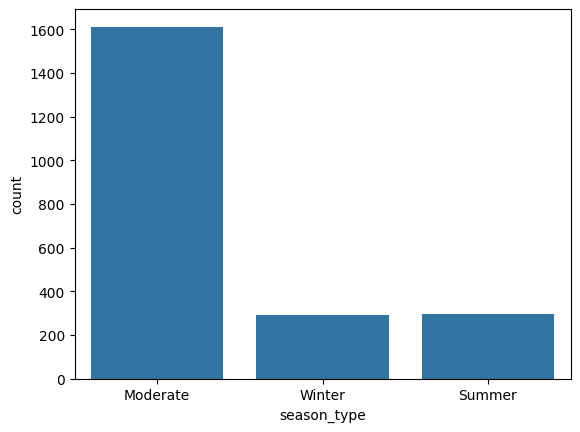

In [17]:
sns.countplot(
    x="season_type",
    data=df
)

In [18]:
import sys
print(sys.executable)

c:\Users\LENOVO\Documents\agri-crop-prediction\venv\Scripts\python.exe


In [19]:
from sklearn.preprocessing import LabelEncoder

print("working")

working


In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["crop_encoded"] = le.fit_transform(df["label"])

df[["label","crop_encoded"]].head()

,label,crop_encoded
0,rice,20
1,rice,20
2,rice,20
3,rice,20
4,rice,20


###  Target Encoding

Machine learning algorithms require numerical target values. Therefore, the crop labels were converted into numerical representations using LabelEncoder.

Example:

- Rice → 20
- Maize → 11
- Chickpea → 3

This encoded column will serve as the target variable (y) during model training.

In [21]:
X = df.drop(
    columns=[
        "label"
    ]
)

y = df["crop_encoded"]

### Defining Features (X) and Target (y)

The dataset was divided into:

- X (features): Agricultural conditions such as N, P, K, temperature, humidity, pH, and rainfall etc.
- y (target): Encoded crop labels.

This separation is required before training machine learning models.

In [22]:
print(X.columns)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall',
       'rainfall_category', 'temperature_category', 'humidity_category',
       'season_type', 'crop_encoded'],
      dtype='str')


###  Feature Verification

The feature columns were reviewed to confirm that all required variables were present before further transformations.

In [23]:
X = pd.get_dummies(
    X,
    columns=[
        "rainfall_category",
        "temperature_category",
        "humidity_category",
        "season_type"
    ]
)

###  One-Hot Encoding

Categorical features (rainfall_category, temperature_category, humidity_category, and season_type) were converted into binary columns using One-Hot Encoding (pd.get_dummies()).

This process transforms each category into separate columns filled with 0s and 1s, enabling machine learning models to understand categorical data without assuming any false numerical order between categories (e.g., High > Medium).

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

X[num_cols] = scaler.fit_transform(X[num_cols])

In [25]:
# Display the first few rows of the original DataFrame and the processed features
print("Original DataFrame (First 5 Rows):")
print(df[num_cols].head())
print("\nProcessed Features (First 5 Rows):")
print(X[num_cols].head())

Original DataFrame (First 5 Rows):
    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536
1  85  58  41    21.770462  80.319644  7.038096  226.655537
2  60  55  44    23.004459  82.320763  7.840207  263.964248
3  74  35  40    26.491096  80.158363  6.980401  242.864034
4  78  42  42    20.130175  81.604873  7.628473  262.717340

Processed Features (First 5 Rows):
          N         P         K  temperature  humidity        ph  rainfall
0  1.068797 -0.344551 -0.101688    -0.935587  0.472666  0.043302  1.810361
1  0.933329  0.140616 -0.141185    -0.759646  0.397051  0.734873  2.242058
2  0.255986  0.049647 -0.081939    -0.515898  0.486954  1.771510  2.921066
3  0.635298 -0.556811 -0.160933     0.172807  0.389805  0.660308  2.537048
4  0.743673 -0.344551 -0.121436    -1.083647  0.454792  1.497868  2.898373


## Feature Scaling with StandardScaler
All numerical features (N, P, K, temperature, humidity, ph, rainfall) were standardized using StandardScaler.
This transformation changes the data so that:

Each feature has a mean of 0
Each feature has a standard deviation of 1

Why it matters:
Without scaling, features like rainfall (range ~20–300) would dominate over features like pH (range ~3.5–9.9). After scaling, all features contribute more equally to the machine learning model.

In [26]:
ml_ready = X.copy()

ml_ready["target"] = y

ml_ready.to_csv(
    "../data/processed/crop_ml_ready.csv",
    index=False
)

print("ML-ready dataset saved!")

ML-ready dataset saved!


In [28]:
print(ml_ready.shape)

ml_ready.head()

(2200, 21)


,N,P,K,temperature,humidity,ph,rainfall,crop_encoded,rainfall_category_Low,rainfall_category_Medium,...,temperature_category_Cool,temperature_category_Moderate,temperature_category_Hot,humidity_category_Low,humidity_category_Medium,humidity_category_High,season_type_Moderate,season_type_Summer,season_type_Winter,target
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361,20,False,False,...,False,True,False,False,False,True,True,False,False,20
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058,20,False,False,...,False,True,False,False,False,True,True,False,False,20
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066,20,False,False,...,False,True,False,False,False,True,True,False,False,20
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048,20,False,False,...,False,True,False,False,False,True,True,False,False,20
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373,20,False,False,...,False,True,False,False,False,True,True,False,False,20
